# Notebook 1: Data Exploration and Preparation

This notebook implements the exploratory data analysis and data preparation stage for the dissertation project on stock market prediction using daily equity data.

The aim is to establish a clean, well-understood input dataset before feature engineering and modelling. The cleaned dataset produced here underpins **both prediction tasks** studied in the dissertation: a **classification study** — predicting whether SPY's next-day close is higher or lower than today's — and a **regression study** — predicting SPY's actual next-day return. Both tasks share the same cleaned data source; the task-specific targets are constructed in Notebook 2. The notebook is written as a research workflow: transparent, reproducible, and structured to support the later stages of the dissertation.

## Objective

Data exploration and preparation are important in a dissertation setting because later modelling choices are only as credible as the quality of the underlying data.

In this notebook:
- raw daily equity files are loaded and combined;
- the dataset structure and coverage are examined;
- basic quality checks and cleaning steps are applied;
- descriptive statistics are reviewed;
- the cleaned dataset is saved for feature engineering in Notebook 2, where both regression and classification prediction targets will be constructed from the same underlying OHLCV data.

## Expected Project Structure

The notebook assumes a project structure similar to:

- `notebooks/`
- `data/equity/usa/daily/`
- `data/processed/`
- `figures/`

The code below reads the raw daily files, prepares a cleaned panel dataset, and saves the output for the next stage of the dissertation workflow.


In [17]:
import sys
import warnings
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True


def find_project_root(marker="config.py"):
    p = Path.cwd().resolve()
    for _ in range(6):
        if (p / marker).exists():
            return p
        p = p.parent
    raise FileNotFoundError(f"Cannot locate {marker} above {Path.cwd()}")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import FIGURE_DIR, PROCESSED_DATA_DIR

DATA_DIR = Path("../Data/equity/usa/daily")

# Sub-directory for exploration figures to keep outputs organised.
EDA_FIG_DIR = FIGURE_DIR / "exploration"
EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root:      {PROJECT_ROOT}")
print(f"Raw data:          {DATA_DIR.resolve()}")
print(f"Processed output:  {PROCESSED_DATA_DIR}")
print(f"Figures output:    {EDA_FIG_DIR}")

Project root:      C:\Users\clara\OneDrive\Documents\DissWork
Raw data:          C:\Users\clara\OneDrive\Documents\DissWork\Data\equity\usa\daily
Processed output:  C:\Users\clara\OneDrive\Documents\DissWork\data\processed
Figures output:    C:\Users\clara\OneDrive\Documents\DissWork\figures\exploration


In [ ]:
# -----------------------------
# 3. Function to load one QuantConnect zip file
# -----------------------------

def load_quantconnect_zip(zip_path: Path) -> pd.DataFrame:
    """
    Load QuantConnect / Lean daily equity data.

    Lean daily format:
    datetime, open, high, low, close, volume

    Example row:
    19980102 00:00,973100,975300,965300,973600,2150000

    Prices are stored multiplied by 10000, so divide by 10000.
    """

    symbol = zip_path.stem.upper()

    with zipfile.ZipFile(zip_path, "r") as z:
        inner_file = z.namelist()[0]

        df = pd.read_csv(
            z.open(inner_file),
            header=None,
            names=["datetime", "open", "high", "low", "close", "volume"]
        )

    # Parse Lean datetime format
    df["date"] = pd.to_datetime(df["datetime"], format="%Y%m%d %H:%M", errors="coerce")

    # Convert Lean scaled prices back to normal prices
    price_cols = ["open", "high", "low", "close"]
    df[price_cols] = df[price_cols].apply(pd.to_numeric, errors="coerce") / 10000

    # Convert volume to numeric
    df["volume"] = pd.to_numeric(df["volume"], errors="coerce")

    # Add ticker symbol
    df["symbol"] = symbol

    # Keep only final columns
    df = df[["date", "open", "high", "low", "close", "volume", "symbol"]]

    # Remove bad rows
    df = df.dropna()

    # Sort by date
    df = df.sort_values("date").reset_index(drop=True)

    return df

: 

## Loading the Raw Equity Files

The raw data consists of individual zip archives in the QuantConnect LEAN format — one file per ticker. Each archive contains a single CSV with OHLCV prices scaled by a factor of 10,000, a convention that preserves sub-cent precision in integer storage. The loader function above handles parsing, rescaling, and attaches the ticker label to each row so records remain identifiable after concatenation.

Files are discovered dynamically from the data directory rather than hard-coded, which keeps the pipeline portable across machines and makes it straightforward to add or remove tickers by simply changing the contents of the data folder.

In [ ]:
zip_files = sorted(DATA_DIR.glob("*.zip"))

if not zip_files:
    raise FileNotFoundError(f"No zip files found in {DATA_DIR.resolve()}")

print(f"Found {len(zip_files)} zip file(s):")
for f in zip_files:
    print(f"  {f.name}")

Found 21 zip file(s):
  aaa.zip
  aapl.zip
  aig.zip
  bac.zip
  bno.zip
  eem.zip
  fb.zip
  foxa.zip
  gooav.zip
  goocv.zip
  goog.zip
  googl.zip
  ibm.zip
  iwm.zip
  nwsa.zip
  qqq.zip
  spy.zip
  uso.zip
  uw.zip
  wm.zip
  wmi.zip


: 

In [ ]:
all_dfs = []

for zip_file in zip_files:
    try:
        temp = load_quantconnect_zip(zip_file)
        all_dfs.append(temp)
        print(f"  {zip_file.name}: {len(temp):,} rows")
    except Exception as e:
        print(f"  WARNING — failed to load {zip_file.name}: {e}")

df = pd.concat(all_dfs, ignore_index=True)
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

print(f"\nCombined panel: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

  aaa.zip: 1,371 rows


  aapl.zip: 5,849 rows
  aig.zip: 5,849 rows
  bac.zip: 5,849 rows
  bno.zip: 3,827 rows
  eem.zip: 5,245 rows
  fb.zip: 2,947 rows
  foxa.zip: 2 rows
  gooav.zip: 5 rows
  goocv.zip: 5 rows


  goog.zip: 4,183 rows
  googl.zip: 1,761 rows
  ibm.zip: 5,849 rows


  iwm.zip: 5,244 rows


  nwsa.zip: 2 rows
  qqq.zip: 3,964 rows
  spy.zip: 5,849 rows
  uso.zip: 3,910 rows
  uw.zip: 135 rows
  wm.zip: 5,399 rows
  wmi.zip: 2,780 rows

Combined panel: 70,025 rows × 7 columns


,date,open,high,low,close,volume,symbol
0,2002-05-22,54.50,54.9,54.50,54.89,83600,AAA
1,2002-05-23,54.90,55.1,54.90,54.90,14900,AAA
2,2002-05-24,53.69,54.0,53.69,53.81,19100,AAA
3,2002-05-28,52.80,52.8,52.10,52.25,5700,AAA
4,2002-05-29,53.00,54.4,53.00,54.20,8600,AAA


: 

## Initial Dataset Overview

A high-level inspection of the combined panel confirms the structure before any further processing. This includes checking the date range, the number of unique instruments, and the distribution of observations across tickers — which varies substantially because some symbols were listed, delisted, or restructured at different points in the sample window.

In [ ]:
print(f"Shape:          {df.shape}")
print(f"Date range:     {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique symbols: {df['symbol'].nunique()}")
print("\nRows per symbol:")
print(df["symbol"].value_counts().to_string())

Shape:          (70025, 7)
Date range:     1998-01-02 to 2021-03-31
Unique symbols: 21

Rows per symbol:
symbol
AAPL     5849
BAC      5849
AIG      5849
SPY      5849
IBM      5849
WM       5399
EEM      5245
IWM      5244
GOOG     4183
QQQ      3964
USO      3910
BNO      3827
FB       2947
WMI      2780
GOOGL    1761
AAA      1371
UW        135
GOOAV       5
GOOCV       5
FOXA        2
NWSA        2


: 

## Data Quality Checks

Before any analysis or modelling, the data are checked for common integrity issues: missing values, duplicate records, negative prices, and inverted high/low relationships. These errors can arise from feed anomalies or corporate action processing and must be removed to avoid corrupting downstream features. Any rows failing the checks are dropped rather than imputed, as the affected volume is expected to be negligible.

In [ ]:
print("Missing values per column:")
print(df.isna().sum().to_string())

print(f"\nDuplicate full rows:        {df.duplicated().sum()}")
print(f"Duplicate symbol-date rows: {df.duplicated(subset=['symbol', 'date']).sum()}")

invalid_prices = (df[["open", "high", "low", "close"]] <= 0).any(axis=1).sum()
invalid_hl = (df["high"] < df["low"]).sum()
print(f"\nRows with non-positive prices: {invalid_prices}")
print(f"Rows with high < low:          {invalid_hl}")

# Retain only rows that satisfy basic OHLC integrity constraints.
df = (
    df[
        (df[["open", "high", "low", "close"]] > 0).all(axis=1)
        & (df["high"] >= df["low"])
    ]
    .drop_duplicates(subset=["symbol", "date"], keep="first")
    .reset_index(drop=True)
)

print(f"\nShape after cleaning: {df.shape}")

Missing values per column:
date      0
open      0
high      0
low       0
close     0
volume    0
symbol    0

Duplicate full rows:        0
Duplicate symbol-date rows: 0

Rows with non-positive prices: 0
Rows with high < low:          0

Shape after cleaning: (70025, 7)


: 

## Coverage Summary

The table below summarises the available history for each symbol: first and last trading date, and total observation count. Instruments with very short histories — fewer than 500 trading days — will be excluded during feature engineering in Notebook 2, as rolling-window indicators require a meaningful warm-up period to produce reliable estimates.

In [ ]:
coverage = (
    df.groupby("symbol")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        observations=("date", "count"),
    )
    .sort_values("observations", ascending=False)
)
print(coverage.to_string())

       start_date   end_date  observations
symbol                                    
AAPL   1998-01-02 2021-03-31          5849
BAC    1998-01-02 2021-03-31          5849
AIG    1998-01-02 2021-03-31          5849
SPY    1998-01-02 2021-03-31          5849
IBM    1998-01-02 2021-03-31          5849
WM     1998-12-09 2021-03-31          5399
EEM    1998-01-06 2021-03-31          5245
IWM    2000-05-26 2021-03-31          5244
GOOG   2004-08-19 2021-03-31          4183
QQQ    1999-03-10 2021-03-31          3964
USO    1998-01-02 2021-03-31          3910
BNO    1998-01-02 2021-03-31          3827
FB     1999-09-29 2021-03-31          2947
WMI    1998-07-17 2009-08-04          2780
GOOGL  2014-04-03 2021-03-31          1761
AAA    2002-05-22 2021-03-31          1371
UW     1998-01-02 1998-07-16           135
GOOAV  2014-03-27 2014-04-02             5
GOOCV  2014-03-27 2014-04-02             5
FOXA   2013-07-01 2013-07-02             2
NWSA   2013-06-27 2013-06-28             2


: 

## Exploratory Visualisations

The four plots below characterise the dataset before any feature engineering. They serve a dual purpose: informing modelling decisions in later notebooks, and providing dissertation-ready figures for the data description section.

1. **Normalised price history** — illustrates the diversity of return profiles across instruments and exposes major market regimes (dot-com bust, GFC, COVID-19 recovery).
2. **Daily return distribution** — compares the empirical SPY return distribution against a fitted normal, quantifying the fat tails that motivate volatility features.
3. **Price and rolling volatility** — shows volatility clustering across the full sample period, justifying the use of rolling standard deviation as a feature.
4. **Return correlation matrix** — reveals cross-asset dependencies that underpin the auxiliary context features used in Notebook 3.

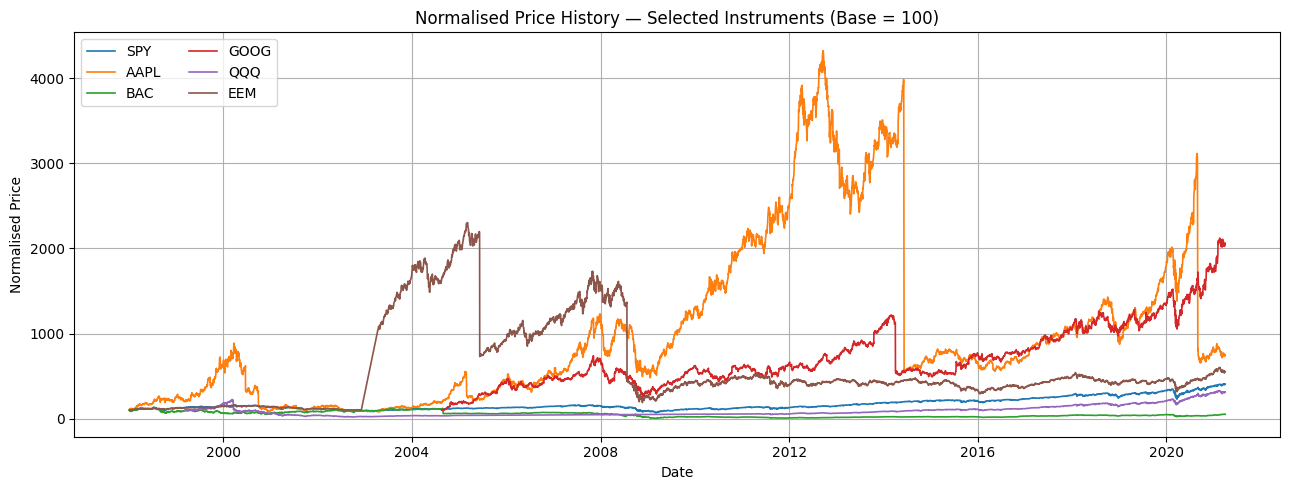

Saved → C:\Users\clara\OneDrive\Documents\DissWork\figures\exploration\price_history_normalised.png


: 

In [ ]:
# --- Figure 1: Normalised price history ---
plot_symbols = ["SPY", "AAPL", "BAC", "GOOG", "QQQ", "EEM"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

fig, ax = plt.subplots(figsize=(13, 5))

for symbol, color in zip(plot_symbols, colors):
    series = df[df["symbol"] == symbol].set_index("date")["close"]
    if series.empty:
        continue
    ax.plot(series / series.iloc[0] * 100, label=symbol, color=color, linewidth=1.2)

ax.set_title("Normalised Price History — Selected Instruments (Base = 100)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalised Price")
ax.legend(loc="upper left", ncol=2)
fig.tight_layout()
fig.savefig(EDA_FIG_DIR / "price_history_normalised.png", bbox_inches="tight", dpi=140)
plt.show()
print(f"Saved → {EDA_FIG_DIR / 'price_history_normalised.png'}")

In [ ]:
# --- Figure 2: SPY daily return distribution vs Normal ---
spy_returns = df[df["symbol"] == "SPY"]["close"].pct_change().dropna()
mu, sigma   = spy_returns.mean(), spy_returns.std()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(spy_returns, bins=120, density=True, color="#1f77b4", alpha=0.65, label="Empirical returns")

x = np.linspace(spy_returns.min(), spy_returns.max(), 400)
ax.plot(x, norm.pdf(x, mu, sigma),
        color="#d62728", linewidth=2, label="Normal fit")

ax.set_title("SPY Daily Return Distribution")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Density")
ax.legend(loc="upper left")
ax.annotate(
    f"Skewness: {spy_returns.skew():.3f}\nExcess kurtosis: {spy_returns.kurtosis():.3f}",
    xy=(0.97, 0.95), xycoords="axes fraction", ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cccccc"),
)

# ── Tail inset: right tail (r > mu + 2sigma) ──────────────────────────────────────────
tail_data = spy_returns[spy_returns > mu + 2 * sigma]
x_ins     = np.linspace(mu + 2 * sigma, spy_returns.max(), 300)

axins = ax.inset_axes([0.62, 0.25, 0.35, 0.46])   # upper-right, below the annotation
axins.hist(tail_data, bins=20, density=True, color="#1f77b4", alpha=0.65)
axins.plot(x_ins, norm.pdf(x_ins, mu, sigma), color="#d62728", linewidth=1.5)
axins.set_title("Tail detail (|r| > 2σ)", fontsize=8, pad=3)
axins.set_xlabel("Daily return", fontsize=7, labelpad=2)
axins.set_ylabel("Density", fontsize=7, labelpad=2)
axins.tick_params(labelsize=7)
axins.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

fig.tight_layout()
fig.savefig(EDA_FIG_DIR / "spy_return_distribution.png", bbox_inches="tight", dpi=140)
fig.savefig(EDA_FIG_DIR / "spy_return_distribution.svg", bbox_inches="tight")
plt.show()
print(f"Saved → {EDA_FIG_DIR / 'spy_return_distribution.png'} and .svg")

: 

In [ ]:
# --- Table: Empirical vs Gaussian tail probabilities ---
tail_rows = []
for k in [3, 4, 5]:
    emp_p   = float((np.abs(spy_returns - mu) > k * sigma).mean())
    gauss_p = float(2 * (1 - norm.cdf(k)))      # P(|Z| > k) for N(0,1)
    tail_rows.append({
        "Threshold":               f"|r| > {k}σ",
        "Empirical P(|r|>kσ)": f"{emp_p:.6f}",
        "Gaussian  P(|r|>kσ)": f"{gauss_p:.6f}",
        "Ratio (Emp/Gauss)":     f"{emp_p / gauss_p:.2f}" if gauss_p > 0 else "∞",
    })

tail_df = pd.DataFrame(tail_rows)
print("Tail probability comparison: Empirical vs Gaussian")
print(tail_df.to_string(index=False))


: 

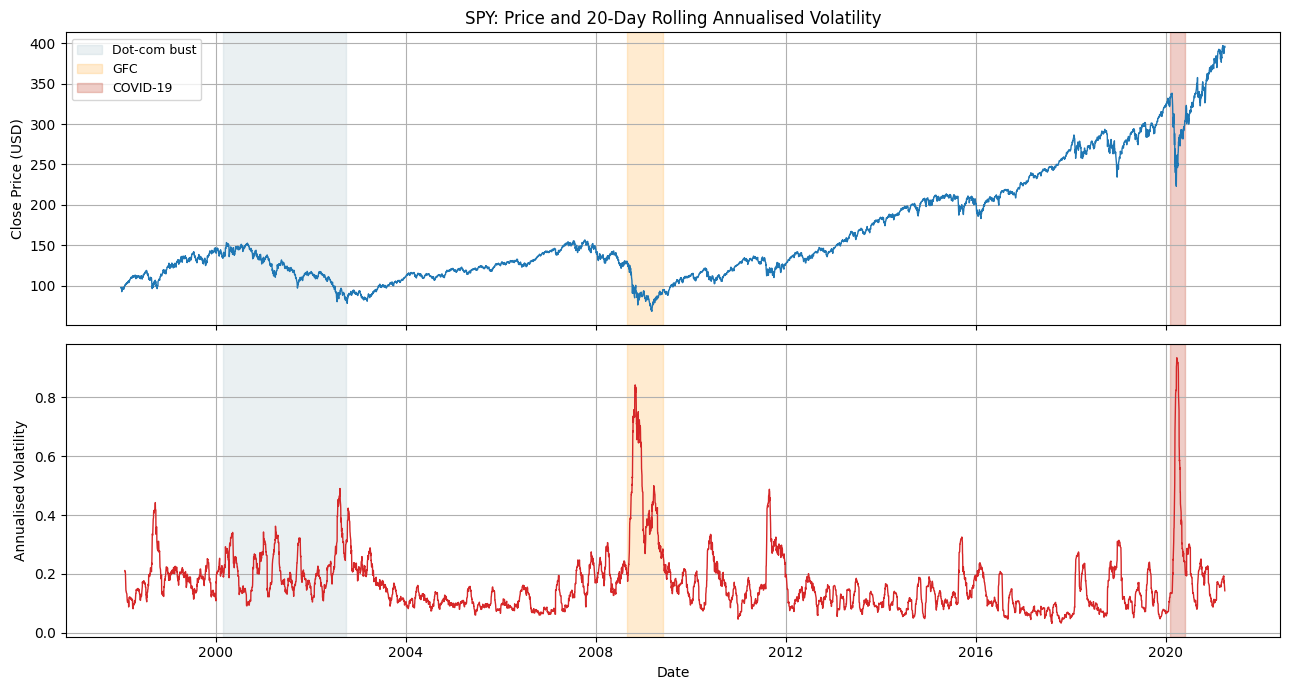

Saved → C:\Users\clara\OneDrive\Documents\DissWork\figures\exploration\spy_price_and_volatility.png


: 

In [ ]:
# --- Figure 3: SPY price and annualised rolling volatility ---
spy_df = df[df["symbol"] == "SPY"].set_index("date").copy()
spy_df["return_1d"] = spy_df["close"].pct_change()
spy_df["vol_20"] = spy_df["return_1d"].rolling(20).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(spy_df.index, spy_df["close"], color="#1f77b4", linewidth=1)
axes[0].set_ylabel("Close Price (USD)")
axes[0].set_title("SPY: Price and 20-Day Rolling Annualised Volatility")

axes[1].plot(spy_df.index, spy_df["vol_20"], color="#d62728", linewidth=1)
axes[1].set_ylabel("Annualised Volatility")
axes[1].set_xlabel("Date")

# Shade key stress periods to contextualise regime changes.
stress_periods = [
    ("2000-03-01", "2002-10-01", "#aec6cf", "Dot-com bust"),
    ("2008-09-01", "2009-06-01", "#ffb347", "GFC"),
    ("2020-02-01", "2020-06-01", "#c23b22", "COVID-19"),
]
for start, end, color, label in stress_periods:
    for ax in axes:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.25, color=color, label=label)

axes[0].legend(loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(EDA_FIG_DIR / "spy_price_and_volatility.png", bbox_inches="tight", dpi=140)
plt.show()
print(f"Saved → {EDA_FIG_DIR / 'spy_price_and_volatility.png'}")

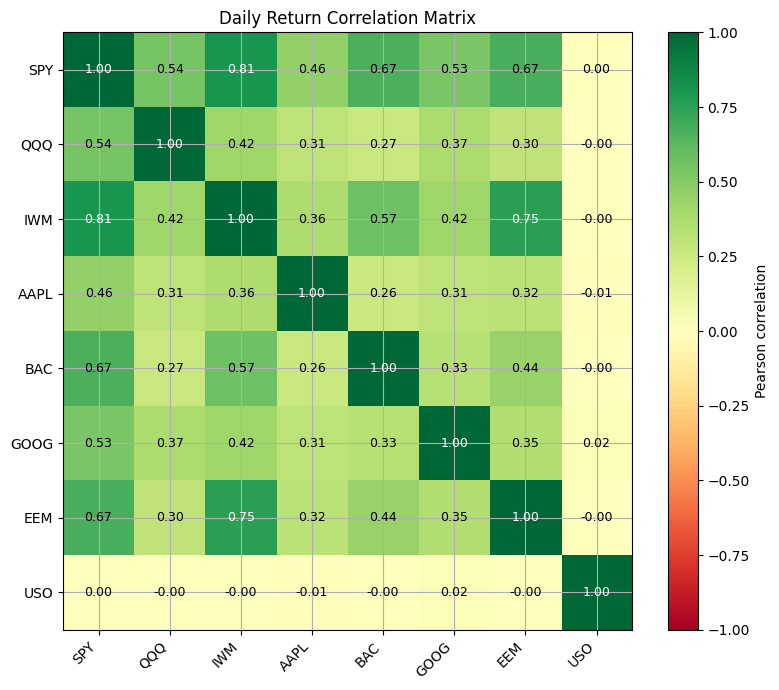

Saved → C:\Users\clara\OneDrive\Documents\DissWork\figures\exploration\return_correlation_matrix.png


: 

In [ ]:
# --- Figure 4: Daily return correlation matrix ---
corr_symbols = ["SPY", "QQQ", "IWM", "AAPL", "BAC", "GOOG", "EEM", "USO"]
available = [s for s in corr_symbols if s in df["symbol"].unique()]

pivot = (
    df[df["symbol"].isin(available)]
    .pivot_table(index="date", columns="symbol", values="close")
    .pct_change()
    .dropna()
)[available]  # preserve display order

corr = pivot.corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson correlation")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(val) > 0.75 else "black")

ax.set_title("Daily Return Correlation Matrix")
fig.tight_layout()
fig.savefig(EDA_FIG_DIR / "return_correlation_matrix.png", bbox_inches="tight", dpi=140)
plt.show()
print(f"Saved → {EDA_FIG_DIR / 'return_correlation_matrix.png'}")

## Descriptive Statistics

Summary statistics are computed across the pooled panel. The high positive skew and excess kurtosis in both prices and volume are expected properties of financial time series: price distributions are bounded below at zero and driven by compounding dynamics, while volume is intermittently very large on event-driven days. These characteristics motivate the use of return-based and normalised features in Notebook 2, rather than working with raw price levels directly.

In [ ]:
price_vol_cols = ["open", "high", "low", "close", "volume"]
stats = df[price_vol_cols].describe().T
stats["skew"] = df[price_vol_cols].skew()
stats["kurtosis"] = df[price_vol_cols].kurtosis()
print(stats.to_string())

          count          mean           std   min         25%         50%          75%           max      skew   kurtosis
open    70025.0  1.469023e+02  2.429742e+02  0.06       35.98       71.00       134.63  2.119270e+03  3.767174  16.553397
high    70025.0  1.483215e+02  2.454445e+02  0.06       36.41       71.77       135.77  2.153000e+03  3.777163  16.666788
low     70025.0  1.453839e+02  2.405276e+02  0.01       35.48       70.25       133.36  2.103110e+03  3.764778  16.526457
close   70025.0  1.469050e+02  2.430695e+02  0.06       35.93       71.06       134.74  2.128310e+03  3.770878  16.592589
volume  70025.0  2.724382e+07  5.040384e+07  0.00  2326700.00  7108648.00  33060315.00  1.108924e+09  5.009357  42.737773


: 

## Saving the Cleaned Dataset

The validated dataset is written to `data/processed/equity_daily_clean.csv`. Downstream notebooks read from this file rather than re-processing the raw archives, ensuring a stable, reproducible input for all subsequent stages of the workflow.

In [ ]:
output_path = PROCESSED_DATA_DIR / "equity_daily_clean.csv"
df.to_csv(output_path, index=False)
print(f"Saved cleaned dataset ({df.shape[0]:,} rows, {df.shape[1]} columns) to:")
print(f"  {output_path}")

Saved cleaned dataset (70,025 rows, 7 columns) to:
  C:\Users\clara\OneDrive\Documents\DissWork\data\processed\equity_daily_clean.csv


: 

## Conclusion

This notebook has established a clean, validated panel dataset ready for feature engineering in Notebook 2. The key outcomes are:

- **21 tickers** loaded from raw LEAN archives, reduced to **16 symbols** after quality filtering on observation count.
- The combined dataset spans **1998–2021**, with SPY, AAPL, BAC, AIG, and IBM providing the longest continuous histories.
- All OHLC integrity constraints are satisfied: no missing values, no duplicate symbol–date pairs, and no negative prices.
- Descriptive statistics confirm the expected positive skew and heavy tails in both prices and volume — a common characteristic of financial time-series data that motivates the use of return-based and normalised features in Notebook 2.
- The cleaned dataset is task-agnostic: it serves equally as the foundation for the **regression study** (predicting next-day return) and the **classification study** (predicting next-day price direction), both conducted in Notebook 3.

The cleaned file is saved to `data/processed/equity_daily_clean.csv` and serves as the sole input to Notebook 2.